# Phase 3: Predictive Modeling

In this notebook, we'll build and compare different machine learning models to predict customer churn.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
import shap


In [2]:
X_train = np.load('../data/X_train.npy')
X_test = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_test = np.load('../data/y_test.npy')
with open('../data/feature_names.pkl', 'rb') as f: feature_names = pickle.load(f)
X_test_df = pd.DataFrame(X_test, columns=feature_names)


In [3]:
models = {'LR': LogisticRegression(max_iter=1000), 'RF': RandomForestClassifier(), 'XGB': XGBClassifier()}
for name, m in models.items():
    m.fit(X_train, y_train)
    print(f'{name} AUC: {roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]):.4f}')


LR AUC: 0.8436


RF AUC: 0.8269


XGB AUC: 0.8208


In [4]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_res, y_res)
print(f'SMOTE RF AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.4f}')


SMOTE RF AUC: 0.8264


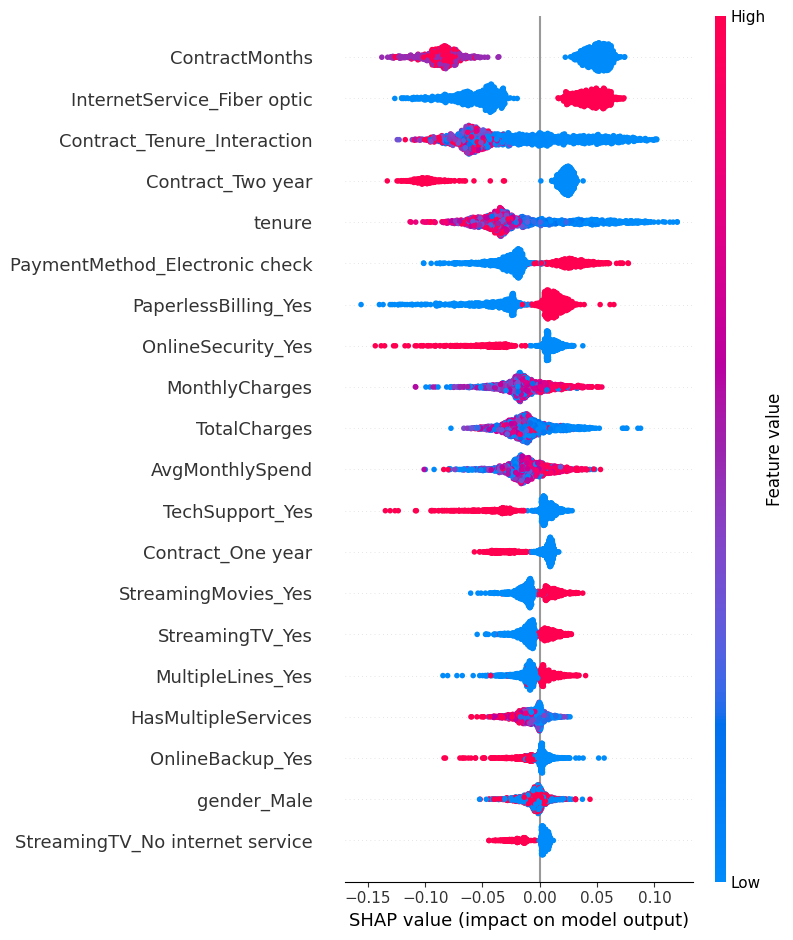

In [5]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
# Handle SHAP output shape
if isinstance(shap_values, list):
    sv = shap_values[1]
elif len(shap_values.shape) == 3:
    sv = shap_values[..., 1]
else:
    sv = shap_values
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test_df, show=False)
plt.savefig('../results/shap_summary_plot.png')
plt.show()


In [6]:
with open('../models/best_model.pkl', 'wb') as f: pickle.dump(rf, f)
